# Full Pipeline 06: Visualize AttentionDQN

This notebook inspects what the custom AttentionDQN attends to over time.

What it does:
- loads the merged RL state
- loads an AttentionDQN checkpoint
- collects attention matrices on a selected split
- plots average attention heatmap and timestep importance

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "full_pipeline").exists() and (candidate / "ml").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root.")

PIPELINE_ROOT = REPO_ROOT / "full_pipeline"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from evaluation import EvaluationConfig
from ml.agents import AttentionDQNAgent
from ml.hyperparameter_config import load_hyperparameter_config
from _pipeline_utils import OUTPUT_DIR, make_rl_env, prepare_rl_inputs

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)

In [17]:
CONFIG_PATH = REPO_ROOT / "configs" / "rl_hyperparameters.yaml"
HP_CONFIG = load_hyperparameter_config(CONFIG_PATH, fast_mode=False)
CFG = HP_CONFIG.values

SEQ_LEN = int(CFG["general"]["sequence_length"])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

state_path = OUTPUT_DIR / "model_state_weekly_hmm_news.csv"

def _prepare_inputs_resilient(path: Path):
    """Load RL inputs and recover if CSV headers contain surrounding whitespace."""
    try:
        return prepare_rl_inputs(state_path=path)
    except ValueError as exc:
        if "Missing column provided to 'parse_dates': 'week_end'" not in str(exc):
            raise

        raw = pd.read_csv(path)
        cleaned = raw.copy()
        cleaned.columns = [str(c).strip() for c in cleaned.columns]

        if "week_end" not in cleaned.columns:
            raise

        cleaned_path = path.with_name(path.stem + "_cleaned.csv")
        cleaned.to_csv(cleaned_path, index=False)
        print(f"Recovered malformed headers. Using cleaned file: {cleaned_path}")
        return prepare_rl_inputs(state_path=cleaned_path)

prepared = _prepare_inputs_resilient(state_path)

eval_config = EvaluationConfig(
    transaction_cost=float(CFG["environment"]["transaction_cost"]),
    risk_penalty=float(CFG["environment"]["volatility_penalty"]),
    risk_window=int(CFG["environment"]["lookback_vol"]),
)

SPLIT = "locked_test"  # change to "validation" if needed
env = make_rl_env(prepared, split=SPLIT, seq_len=SEQ_LEN, config=eval_config)

state_dim = int(env.observation_space.shape[-1])
action_dim = int(env.action_space.n)

display(prepared["dataset"].describe_splits())
print("Using split:", SPLIT)
print("State dim:", state_dim, "| Action dim:", action_dim, "| Seq len:", SEQ_LEN)

Recovered malformed headers. Using cleaned file: /home/yuaylong/Market-Regime-Detection-for-RL-Allocation/output/full_pipeline/model_state_weekly_hmm_news_cleaned.csv


,split,rows,start,end
0,warmup,14,2014-03-28,2014-06-27
1,train,339,2014-07-04,2020-12-25
2,validation,105,2021-01-01,2022-12-30
3,locked_test,167,2023-01-06,2026-03-13


Using split: locked_test
State dim: 77 | Action dim: 7 | Seq len: 4


In [18]:
agent = AttentionDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    seq_len=SEQ_LEN,
    learning_rate=float(CFG["dqn"]["learning_rate"]),
    gamma=float(CFG["dqn"]["gamma"]),
    epsilon_start=float(CFG["dqn"]["exploration_initial_eps"]),
    epsilon_end=float(CFG["dqn"]["exploration_final_eps"]),
    epsilon_decay=3000,
    buffer_capacity=int(CFG["dqn"]["buffer_size"]),
    batch_size=int(CFG["dqn"]["batch_size"]),
    target_update_freq=max(250, int(CFG["dqn"]["target_update_interval"] // 4)),
    use_dueling=True,
    device=DEVICE,
)

checkpoint_candidates = [
    OUTPUT_DIR / "attention_dqn_hmm_news_finetuned.pt",
    OUTPUT_DIR / "attention_dqn_hmm_news_base.pt",
    REPO_ROOT / "output" / "models" / "attention_dqn_agent.pt",
]

checkpoint_path = next((p for p in checkpoint_candidates if p.exists()), None)
if checkpoint_path is None:
    raise FileNotFoundError("No AttentionDQN checkpoint found. Run Notebook 04 export/training first.")

agent.load_checkpoint(str(checkpoint_path))
print("Loaded checkpoint:", checkpoint_path.relative_to(REPO_ROOT))

Checkpoint loaded from /home/yuaylong/Market-Regime-Detection-for-RL-Allocation/output/full_pipeline/attention_dqn_hmm_news_finetuned.pt
Loaded checkpoint: output/full_pipeline/attention_dqn_hmm_news_finetuned.pt


In [19]:
def normalize_attention(attention):
    """Convert returned attention tensor/array into a [seq_len, seq_len] matrix."""
    arr = np.asarray(attention)

    # Expected possibilities:
    # [1, heads, seq, seq], [heads, seq, seq], or [seq, seq]
    if arr.ndim == 4:
        arr = arr[0]
    if arr.ndim == 3:
        arr = arr.mean(axis=0)
    if arr.ndim != 2:
        raise ValueError(f"Unexpected attention shape: {arr.shape}")

    return arr

n_features = len(prepared["feature_cols"])
n_regimes = len(prepared["posterior_cols"])
regime_start = n_features
regime_end = n_features + n_regimes
regime_labels = [c.replace("filtered_prob_regime_", "regime_") for c in prepared["posterior_cols"]]

obs, _ = env.reset()
done = False

attention_mats = []
actions = []
rewards = []
step_idx = []
key_regime_sequences = []
observations = []

step = 0
while not done:
    att = agent.get_attention_weights(obs)
    att_mat = normalize_attention(att)

    regime_probs = obs[:, regime_start:regime_end]
    key_regimes = np.argmax(regime_probs, axis=1).astype(int)

    observations.append(obs.copy())

    action = agent.select_action(obs, training=False)
    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = bool(terminated or truncated)

    attention_mats.append(att_mat)
    actions.append(int(action))
    rewards.append(float(reward))
    step_idx.append(step)
    key_regime_sequences.append(key_regimes)

    obs = next_obs
    step += 1

obs_stack = np.stack(observations, axis=0)
attention_stack = np.stack(attention_mats, axis=0)
mean_attention = attention_stack.mean(axis=0)

# Average key-side importance across query positions.
timestep_importance = mean_attention.mean(axis=0)

# Regime-conditioned attention (aggregated across query and key positions).
regime_pair_sum = np.zeros((n_regimes, n_regimes), dtype=float)
regime_pair_count = np.zeros((n_regimes, n_regimes), dtype=float)

regime_key_rows = []
for i, att_mat in enumerate(attention_mats):
    seq_reg = key_regime_sequences[i]
    for q in range(att_mat.shape[0]):
        q_reg = int(seq_reg[q])
        for k in range(att_mat.shape[1]):
            k_reg = int(seq_reg[k])
            w = float(att_mat[q, k])
            regime_pair_sum[q_reg, k_reg] += w
            regime_pair_count[q_reg, k_reg] += 1.0

    # Key importance seen from the latest query step in the sequence.
    latest_query_weights = att_mat[-1]
    for key_pos, weight in enumerate(latest_query_weights):
        regime_key_rows.append(
            {
                "step": i,
                "key_pos": int(key_pos),
                "key_regime_id": int(seq_reg[key_pos]),
                "attention": float(weight),
            }
        )

regime_pair_attention = np.divide(
    regime_pair_sum,
    np.maximum(regime_pair_count, 1.0),
)

regime_key_df = pd.DataFrame(regime_key_rows)
regime_importance = (
    regime_key_df.groupby("key_regime_id", as_index=False)["attention"]
    .mean()
    .sort_values("key_regime_id")
)
regime_importance["regime"] = regime_importance["key_regime_id"].map(lambda i: regime_labels[int(i)])

rollout_df = pd.DataFrame(
    {
        "step": step_idx,
        "action_id": actions,
        "reward": rewards,
    }
)

print("Collected state stack:", obs_stack.shape)
print("Collected attention matrices:", attention_stack.shape)
display(rollout_df.head())
display(regime_importance)

Collected state stack: (167, 4, 77)
Collected attention matrices: (167, 4, 4)


,step,action_id,reward
0,0,2,0.011959
1,1,3,0.001466
2,2,3,-0.001031
3,3,3,-0.033225
4,4,3,-0.001290


,key_regime_id,attention,regime
0,0,0.252555,regime_0
1,1,0.242576,regime_1


## How To Read The Main Attention Figure

This section visualizes attention at both sequence and regime levels.

- Top-left (Mean Attention Matrix): average temporal attention from each query position (row) to each key position (column).
- Top-right (Average Attention by Timestep Position): marginal key importance by sequence position.
- Bottom-left (Regime-to-Regime Attention): average attention weight when query and key positions are tagged by inferred regime.
- Bottom-right (Attention to Key Regime): mean attention received by each key regime from the latest query step.

Interpretation notes:
- If values are concentrated, the model is selectively using specific history positions or regimes.
- If values are near-uniform, the model is using broad context rather than sharp focus.

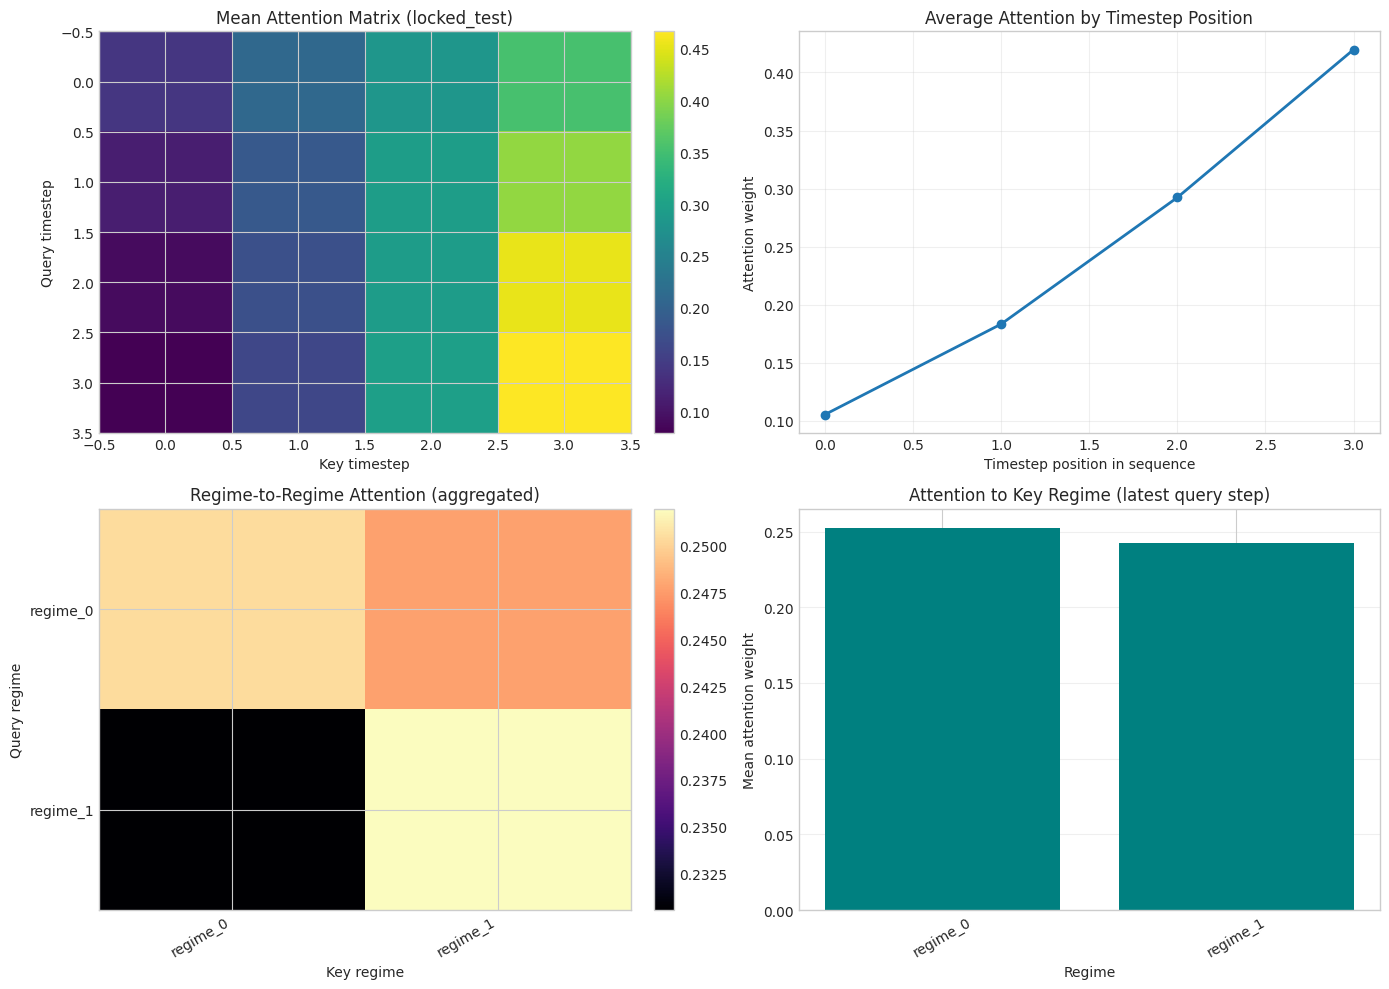

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im = axes[0, 0].imshow(mean_attention, aspect="auto", cmap="viridis")
axes[0, 0].set_title(f"Mean Attention Matrix ({SPLIT})")
axes[0, 0].set_xlabel("Key timestep")
axes[0, 0].set_ylabel("Query timestep")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].plot(np.arange(len(timestep_importance)), timestep_importance, marker="o", linewidth=2)
axes[0, 1].set_title("Average Attention by Timestep Position")
axes[0, 1].set_xlabel("Timestep position in sequence")
axes[0, 1].set_ylabel("Attention weight")
axes[0, 1].grid(True, alpha=0.3)

im2 = axes[1, 0].imshow(regime_pair_attention, aspect="auto", cmap="magma")
axes[1, 0].set_title("Regime-to-Regime Attention (aggregated)")
axes[1, 0].set_xlabel("Key regime")
axes[1, 0].set_ylabel("Query regime")
axes[1, 0].set_xticks(np.arange(len(regime_labels)))
axes[1, 0].set_yticks(np.arange(len(regime_labels)))
axes[1, 0].set_xticklabels(regime_labels, rotation=30, ha="right")
axes[1, 0].set_yticklabels(regime_labels)
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].bar(regime_importance["regime"], regime_importance["attention"], color="teal")
axes[1, 1].set_title("Attention to Key Regime (latest query step)")
axes[1, 1].set_xlabel("Regime")
axes[1, 1].set_ylabel("Mean attention weight")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## Attention Concentration Diagnostics

This section checks whether attention is informative or close to uniform.

Metrics:
- min/max/mean/std of attention weights.
- uniform_weight: baseline for a flat distribution (for seq_len=4, this is 0.25).
- avg_l1_to_uniform: average distance from a flat attention vector.
- avg_norm_entropy: normalized entropy in [0, 1]. Closer to 1 means more diffuse.
- avg_top1_share: average largest attention weight per step.

Rule of thumb:
- High entropy with low top1 share implies diffuse attention.
- Lower entropy and higher top1 share imply stronger concentration.

,metric,value
0,min_weight,0.028964
1,max_weight,0.652564
2,mean_weight,0.251255
3,std_weight,0.159676
4,uniform_weight,0.250000
5,avg_l1_to_uniform,0.541843
6,avg_norm_entropy,0.854312
7,avg_top1_share,0.472054


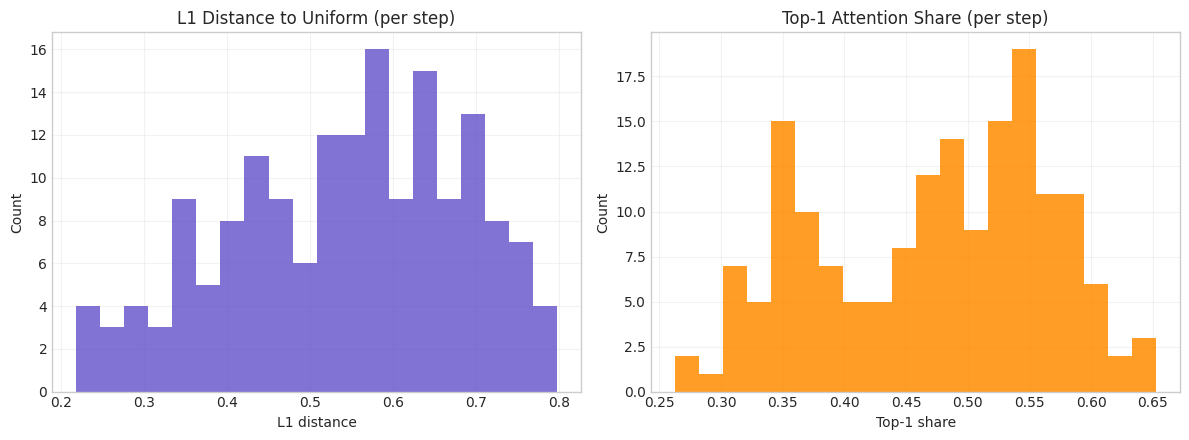

Interpretation: attention is moderately diffuse.


In [21]:
# Attention concentration diagnostics (latest query step across rollout)
latest_query_att = attention_stack[:, -1, :]  # [n_steps, seq_len]
uniform = np.full(latest_query_att.shape[1], 1.0 / latest_query_att.shape[1])

att_min = float(latest_query_att.min())
att_max = float(latest_query_att.max())
att_mean = float(latest_query_att.mean())
att_std = float(latest_query_att.std())

# L1 distance to uniform: 0 means perfectly uniform.
l1_to_uniform = np.abs(latest_query_att - uniform).sum(axis=1)

# Normalized entropy: 1 means fully uniform, 0 means one-hot concentration.
eps = 1e-12
entropy = -(latest_query_att * np.log(latest_query_att + eps)).sum(axis=1)
max_entropy = np.log(latest_query_att.shape[1])
normalized_entropy = entropy / max_entropy

# Top-1 key concentration per step.
top1_share = latest_query_att.max(axis=1)

diagnostics = pd.DataFrame(
    {
        "metric": [
            "min_weight",
            "max_weight",
            "mean_weight",
            "std_weight",
            "uniform_weight",
            "avg_l1_to_uniform",
            "avg_norm_entropy",
            "avg_top1_share",
        ],
        "value": [
            att_min,
            att_max,
            att_mean,
            att_std,
            float(uniform[0]),
            float(l1_to_uniform.mean()),
            float(normalized_entropy.mean()),
            float(top1_share.mean()),
        ],
    }
)

display(diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(l1_to_uniform, bins=20, color="slateblue", alpha=0.85)
axes[0].set_title("L1 Distance to Uniform (per step)")
axes[0].set_xlabel("L1 distance")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.25)

axes[1].hist(top1_share, bins=20, color="darkorange", alpha=0.85)
axes[1].set_title("Top-1 Attention Share (per step)")
axes[1].set_xlabel("Top-1 share")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

if normalized_entropy.mean() > 0.95:
    print("Interpretation: attention is very diffuse (close to uniform).")
elif normalized_entropy.mean() > 0.85:
    print("Interpretation: attention is moderately diffuse.")
else:
    print("Interpretation: attention shows meaningful concentration.")

## Feature Attribution XAI (Gradient x Input)

This section explains which input features drive the chosen action values.

Method:
- For each rollout state, compute gradient of Q(chosen_action) with respect to input state.
- Use absolute Gradient x Input as attribution score.
- Aggregate by timestep position and by semantic groups:
  price, macro, text, regime posterior, previous allocation.

How to read:
- Higher attribution means stronger influence on the selected action value.
- If regime group attribution is high, policy behavior is regime-sensitive.
- If allocation-history attribution is high, policy may be path-dependent.

,group,attribution
1,macro,0.061651
0,price,0.047090
2,text,0.006942
3,regime,0.001509
4,prev_alloc,0.001063


,feature,attribution
0,dff_level,0.012420
1,t10y3m_sign,0.009353
2,tnx_level,0.006820
3,umcsent_level,0.006714
4,spy_tlt_corr_20d,0.005228
5,qqq_spy_log_ratio,0.004524
6,dgs10_level,0.004500
7,permit_yoy,0.004238
8,umcsent_chg_3m,0.004004
9,t10yie_level,0.003912


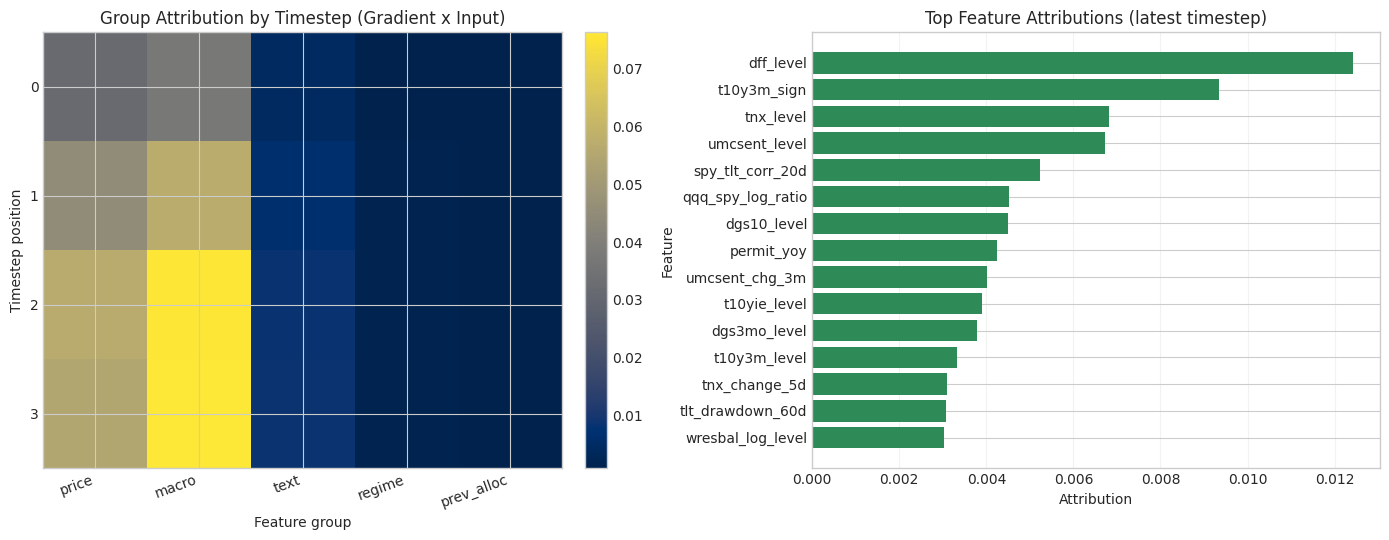

In [22]:
# Gradient x Input attribution for chosen actions along the rollout.
was_training = agent.q_network.training
agent.q_network.train()

feature_names = list(prepared["feature_cols"]) + regime_labels + [
    "prev_alloc_spy",
    "prev_alloc_tlt",
    "prev_alloc_gld",
    "prev_alloc_cash",
]

n_price = len(prepared["dataset"].feature_groups.price)
n_macro = len(prepared["dataset"].feature_groups.macro)
n_text = len(prepared["dataset"].feature_groups.text)

group_slices = {
    "price": slice(0, n_price),
    "macro": slice(n_price, n_price + n_macro),
    "text": slice(n_price + n_macro, n_features),
    "regime": slice(regime_start, regime_end),
    "prev_alloc": slice(regime_end, regime_end + 4),
}

attr_rows = []
attr_tensors = []
for i in range(obs_stack.shape[0]):
    state_np = obs_stack[i]
    chosen_action = int(actions[i])

    state_t = torch.tensor(state_np, dtype=torch.float32, device=agent.device).unsqueeze(0)
    state_t.requires_grad_(True)

    with torch.backends.cudnn.flags(enabled=False):
        q_vals, _ = agent.q_network(state_t)
        target = q_vals[0, chosen_action]

        agent.q_network.zero_grad(set_to_none=True)
        target.backward()

    grad = state_t.grad.detach().cpu().numpy()[0]
    gx = np.abs(grad * state_np)
    attr_tensors.append(gx)

attr_stack = np.stack(attr_tensors, axis=0)  # [steps, seq_len, state_dim]
mean_attr = attr_stack.mean(axis=0)  # [seq_len, state_dim]

# Group-level attribution by timestep and globally.
group_ts_rows = []
group_global = []
for group_name, sl in group_slices.items():
    vals_ts = mean_attr[:, sl].sum(axis=1)
    group_global_val = float(vals_ts.mean())
    group_global.append({"group": group_name, "attribution": group_global_val})

    for t in range(vals_ts.shape[0]):
        group_ts_rows.append(
            {
                "timestep_pos": int(t),
                "group": group_name,
                "attribution": float(vals_ts[t]),
            }
        )

group_ts_df = pd.DataFrame(group_ts_rows)
group_global_df = pd.DataFrame(group_global).sort_values("attribution", ascending=False)

# Top features at the latest query timestep.
latest_attr = mean_attr[-1]
top_k = min(15, len(feature_names))
top_idx = np.argsort(latest_attr)[-top_k:][::-1]
top_feature_df = pd.DataFrame(
    {
        "feature": [feature_names[j] for j in top_idx],
        "attribution": [float(latest_attr[j]) for j in top_idx],
    }
)

display(group_global_df)
display(top_feature_df)

# Plot group attribution heatmap and top features.
groups = list(group_slices.keys())
heat = np.zeros((SEQ_LEN, len(groups)), dtype=float)
for gi, gname in enumerate(groups):
    vals = group_ts_df.loc[group_ts_df["group"] == gname, "attribution"].to_numpy(dtype=float)
    heat[: len(vals), gi] = vals

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

im = axes[0].imshow(heat, aspect="auto", cmap="cividis")
axes[0].set_title("Group Attribution by Timestep (Gradient x Input)")
axes[0].set_xlabel("Feature group")
axes[0].set_ylabel("Timestep position")
axes[0].set_xticks(np.arange(len(groups)))
axes[0].set_xticklabels(groups, rotation=20, ha="right")
axes[0].set_yticks(np.arange(SEQ_LEN))
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].barh(top_feature_df["feature"][::-1], top_feature_df["attribution"][::-1], color="seagreen")
axes[1].set_title("Top Feature Attributions (latest timestep)")
axes[1].set_xlabel("Attribution")
axes[1].set_ylabel("Feature")
axes[1].grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

if not was_training:
    agent.q_network.eval()

## Interpreting The XAI Attribution Output

Use this section as a quick reading guide:

- Group attribution table:
  higher values mean the policy relies more on that feature family when scoring the chosen action.
- Top feature table:
  ranks individual features by average absolute Gradient x Input at the latest timestep.
- Left heatmap (group by timestep):
  shows when each feature group matters in the lookback window.
  stronger intensity near recent timesteps means recency-driven decisions.
- Right bar chart (top features):
  highlights the most influential raw drivers for chosen actions.

Practical interpretation:
- Regime-driven policy: regime group is consistently high and regime features appear in top ranks.
- Macro-driven policy: macro group dominates and rates/slope features appear repeatedly.
- Path-dependent policy: prev_alloc group is high, meaning allocation history strongly influences decisions.

## Action-Conditioned Attention View

This optional section groups attention by selected action.

Purpose:
- Compare whether the model shifts temporal focus when it chooses different portfolio templates.
- Detect action-specific patterns such as defensive actions emphasizing different history positions than risk-on actions.

Caution:
- If an action appears rarely, its curve may be noisy due to low sample size.

,action_id,timestep_pos,attention
0,0,0,0.117187
1,0,1,0.195212
2,0,2,0.285374
3,0,3,0.397675
4,1,0,0.151744
5,1,1,0.217192
6,1,2,0.295259
7,1,3,0.361940
8,2,0,0.097264
9,2,1,0.177546


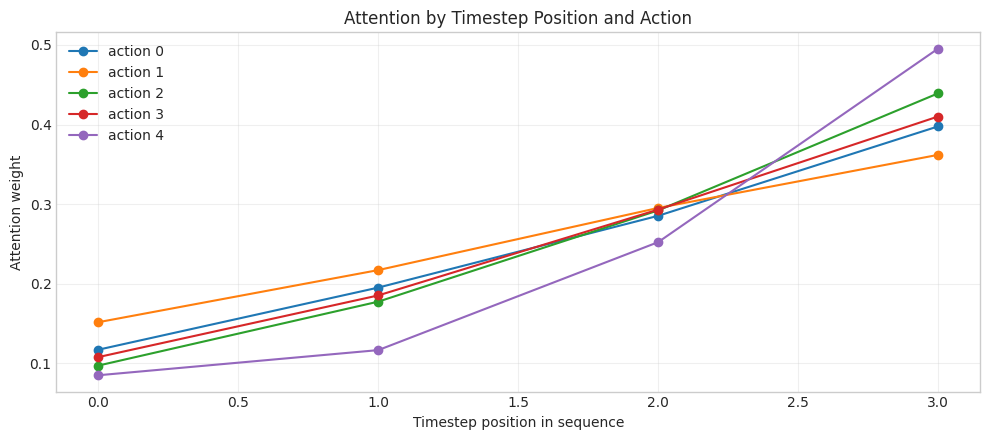

In [23]:
# Optional: view attention grouped by chosen action.
action_group_rows = []
for action_id in sorted(set(actions)):
    idx = [i for i, a in enumerate(actions) if a == action_id]
    if not idx:
        continue
    action_mean = attention_stack[idx].mean(axis=0).mean(axis=0)
    for pos, val in enumerate(action_mean):
        action_group_rows.append({"action_id": action_id, "timestep_pos": pos, "attention": float(val)})

action_attention_df = pd.DataFrame(action_group_rows)
display(action_attention_df.head(20))

if not action_attention_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for action_id, grp in action_attention_df.groupby("action_id"):
        ax.plot(grp["timestep_pos"], grp["attention"], marker="o", label=f"action {action_id}")

    ax.set_title("Attention by Timestep Position and Action")
    ax.set_xlabel("Timestep position in sequence")
    ax.set_ylabel("Attention weight")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()